# 3D Adhesion Notebook
Calculates adhesive energies between two flat shells for various separation distances.

In [1]:
import numpy as np
import os
import sys
import gzip
import subprocess
import importlib
import pathlib
import shutil
import yaml
import datetime
import pytz
import time
from scipy.optimize import curve_fit
cwd = os.getcwd()
itop=cwd.find("cgshells/")+len("cgshells")
PROJECT_ROOT = cwd[:itop]
sys.path.insert(0, PROJECT_ROOT )

from utils.readsim import ReadSim
# from utils.curvsim.v1.curvamer2d import Curvamer2D
# from utils.curvsim.v1.curvamer3d import Curvamer3D
import utils.run_manager as rm
# from utils.run_manager import PROJECT_ROOT, lmpunity, lmplocal
version = "v1"    # select which version of curvsim to use
curvsim = importlib.import_module(f"utils.curvsim.{version}")
Curvamer2D = rm.load_class(version, "curvamer2d", "Curvamer2D")
Curvamer3D = rm.load_class(version, "curvamer3d", "Curvamer3D")
versionpath = "/".join(curvsim.__name__.split("."))
DATASCRIPTS = f"{versionpath}/DataScripts"    # location of compatible data scripts (relative to PROJECT_ROOT)

# rm.print_header(version)
# rm.make_simpaths_file(JOBDIR,JOB)     # make empty status file for this job

import matplotlib as mpl
import matplotlib.pyplot as plt

%matplotlib inline


# Run calculations

In [64]:
emin_list

[3521.85194395847]

In [145]:
1/np.array(emin_list)

array([2.36282707e-05])

In [143]:
epsilon_list

[2.362827066414215e-05]

In [150]:
float(epsilon)

2.362827066414215e-05

In [154]:
f"{epsilon:0.9f}"

'0.000023628'

In [155]:
ysep

'a'

In [146]:
simpath = f"data/{int(dimension)}d/mesh_characteristics/{mesh_name}/t0-{t0:0.3f}/interactions/{pair_ints}/sigma-{sigma:0.5f}-epsilon-{epsilon:0.9f}-soft-{soft_ints}/ysep-{ysep:0.3f}"

ValueError: Unknown format code 'f' for object of type 'str'

In [11]:
tstart = time.time()

dimension = 3
dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
wx = 30 * dcore    # mesh width in x 
wy = 30 * dcore    # mesh width in y 
a = 0.316 * dcore    # lattice constant of mesh
mesh_name = f"a-{a:.3f}-wx-{wx:.2f}-wy-{wy:.2f}"    # name of bead-spring mesh to use for shell
t0 = 1.0 * dcore    # structural thickness

sigma_list = [0.3,0.35]
# sigma_list = [0.25,0.410829,0.636787,0.899922]
# epsilon_list = np.ones(len(sigma_list)).tolist()
epsilon_list =  (1/np.array(emin_list)).tolist()
ysep_list = np.linspace((t0+dcore)*0.8,(t0+dcore)*1.2,200).tolist() 
# ysep_list = np.linspace((t0+dcore)*0.8,2,100).tolist() 
# ysep_list = np.linspace(1.9,2.2,100).tolist() 

jobcounter = 0
for i in range(len(sigma_list)):   
    
    simcounter = 0
    jobcounter += 1
    
    print("#####################################\n")
    print(f"Setting up job {jobcounter}...")
    
    series_simpaths = [] # append simpaths that will run in series for each job (i.e. different kh values)
    
    for j in range(len(ysep_list)):  
        
        simcounter += 1
        
        print(f"----Preparing simulation {simcounter}...")

        ##### PARTICLE #####
        ### Geometry

        r0 = "flat"   # RMS radius of curvature; set to "flat" for planar plates 
        alpha = 0    # shape 'angle' (0 = cylinder w/ curvature in x; pi/4 = sphere; -pi/4 = saddle) 
        theta = 0    # angle principal direction 1 makes with material x-axis

        if r0 == "flat":
            k_0 = 0
        else:
            k_0 = 1/r0    # RMS curvature
        
        # preferred curvatures
        k01 = k_0 * np.cos(alpha)    # principal curvatures
        k02 = k_0 * np.sin(alpha)
        kx_0 = k01 * np.cos(theta)**2 + k02 * np.sin(theta)**2  # curvatures in material directions x, y, xy
        ky_0 = k01 * np.sin(theta)**2 + k02 * np.cos(theta)**2
        kxy_0 = (k01-k02) * np.sin(theta) * np.cos(theta)
        

        ### Elasticity
        kh = 1 # all values in this section are arbitrary
        nuxy = 0.333
        nuz = 0.001
        kvkh = (3*(1-3*nuxy)*(1-nuxy-2*nuz*(t0/a)**2))/(2*nuz*(4*nuz*(t0/a)**2+3*nuxy-1))
        kckh = ((1-3*nuxy)*(1+(t0/a)**2))/(4*nuz*(t0/a)**2+3*nuxy-1)

#         kvkh = 1 
#         kckh = 1 

        ### Interactions
        pair_ints = "patchy" #"none", "repulsive", "1patch", "patchy", "attractive", or "2attractive"
        soft_ints = False
        sigma = sigma_list[i]
        epsilon = epsilon_list[i]
        shift = dcore - 2**(1/6)*sigma     # shift factor to make sure lj minimum is at dcore
        ljcut = 5*sigma #t0 + 2*dcore               # cutoff distance for attractive lj potential
        wcacut = dcore    # cutoff distance for repulsive wca potential
        softsigma = 5*sigma
        softepsilon = 5e-8 * epsilon
        softshift = 0 #softcore - 2**(1/6)*softsigma
        softcut = 2**(1/6) * softsigma

        ##### SIMULATION #####
        ysep = ysep_list[j]
        config = "stacked" #"dispersed" or "stacked"
        simtype = "emin"
        datascript = "ysep3D"    # script to make data file with, NO .py EXTENSION, "stack3D", "load3D", or "lattice3D"
        nshells = 2
        datagz = True
        trajgz = True
        dumpbonds = False    # whether to calculate and dump bond data
        screen = True    # output lammps log to screen


        ### Stacked config settings
        ki1 = 0 * k01    # principal curvatures for bottom shell in stack
        ki2 = 0 * k02
        theta_i = theta
        kx_i = ki1 * np.cos(theta_i)**2 + ki2 * np.sin(theta_i)**2  # curvatures in material directions x, y, xy
        ky_i = ki1 * np.sin(theta_i)**2 + ki2 * np.cos(theta_i)**2
        kxy_i = (ki1-ki2) * np.sin(theta_i) * np.cos(theta_i)
        xlo = -2*wx
        xhi = 2*wx
        ylo = -2*wy
        yhi = 2*wy
        if r0 != 'flat':
            zlo = -4*r0
            zhi = nshells*r0 + 4*r0
        else:
            zlo = -5*(t0+dcore)
            zhi = nshells*(t0+dcore) + 5*(t0+dcore)

        ### Lattice config settings
#         Nx = 2    # number of particle columns for initial config 
#         Ny = int(nshells/Nx)
#         nshells = int(Nx*Ny)   # true number of shells in simulation
#         k_i = 0    # initial curvature of shells in lattice (need flat for high concentrations)
#         theta = "random"   # orientation of shells in lattice (0 = concave down, np.pi = concave up, "random" = randomly up or down)

        ### Dispersed config settings
#         phi = 0.1    # concentration of molecules (area fraction) - only for MD
#         v0 = wx * (t0 + dcore)    # approx area of monomer
#         lbox = np.sqrt(nshells * v0 / phi)    # side length of (square) sim box to give proper concentration
#         xlo = -lbox/2
#         xhi = lbox/2
#         ylo = -lbox/2
#         yhi = lbox/2
#         zlo = -0.5
#         zhi = 0.5

        ### Dynamics/Minimization Settings
        minstyle = "cg"
        etol = 1e-12
        maxiter = 100000

#         Tstart = 1.0
#         Tstop = Tstart
#         Tdamp = 10
#         seed = 15298
#         timestep = 0.0005
#         runsteps = 10000

        dumpfreq = maxiter
        thermofreq = 100

#         force  = 0.1

        ##### LOGISTICS #####

        ### Simulation Directories
        delete_existing = True    # if True, deletes simulation directory (and .sh files) if it exists before creating again
        simpath = f"data/{int(dimension)}d/mesh_characteristics/{mesh_name}/t0-{t0:0.3f}/interactions/{pair_ints}/sigma-{sigma:0.5f}-epsilon-{epsilon:0.9f}-soft-{soft_ints}/ysep-{ysep:0.3f}"
        load_simpath = False # location of simulation to load in (set to False if not loading in state)
#         load_simpath = f"data/examples/{int(dimension)}d/emin/kh-{kh_load:0.2f}/nshells-{nshells}" # location of simulation to load in (set to False if not loading in state)
#         load_dumpname = -1 # name of trajectory file to load (-1 selects highest integer found, e.g trajectory2.dump)
#         load_frame = -1    # frame number to load in (not timestep! 0 is initial state; -1 is last completed dump)

        ### Computation
        computer = "local"
#         computer = "unity"
        nnodes = 1
        mem = 1 #GB
        tlim_hrs = 1
        tlim_min = 0
        partition = "cpu-preempt"    # requested partition
        jobname = os.path.splitext(os.path.basename(sys.argv[0]))[0]
        requested_walltime = f'{tlim_hrs:02d}:{tlim_min:02d}:00'
        tbuffer = 5 # stop lammps tbuffer minutes before walltime is exceeded
                        # any non-zero value means script will auto resubmit until done
                        # zero means no auto resubmission - job stops when done or if time is exceeded
        px = 2    # number of cpus along x
        py = 2
        pz = 1
        gridfreq = 10000    # check cpu partitioning of simbox every gridfreq steps
        thresh = 1.01    # threshold imbalance to repartition simbox
        maxrestarts = 10    # max number of runs for one job (cluster only, local machine limit is set below to 5)

        # add tstep start variable?
        
        
        #################
        ##### SETUP #####
        #################
        
        print("--------Creating simulation directory...")
        
        ### Make simulation directory
        
        if delete_existing == True:
            if os.path.isdir(f"{PROJECT_ROOT}/{simpath}"):
                print("""----------Simulation directory already exists.
----------Deleting...""")
                shutil.rmtree(f"{PROJECT_ROOT}/{simpath}")
                print("----------Creating new simulation directory...")
        
        os.makedirs(f"{PROJECT_ROOT}/{simpath}", exist_ok=True)
        
        ### Append simpaths to job status file and to series_simpaths
#         print("--------Adding simulation directory to job simpaths file...")
#         rm.update_simpaths_file(JOBDIR,JOB,simpath)
        series_simpaths.append(simpath)

        ###############################
        ##### LAMMPS INPUT SCRIPT #####
        ###############################

        print("--------Writing LAMMPS input file...")
        
        ### Header
        inputcontents = f"""# Coarse-grained shell model - LAMMPS input file
        
units lj
dimension {dimension}
boundary s s s
atom_style molecular
bond_style harmonic
angle_style none
dihedral_style none
improper_style none

processors {px} {py} {pz} grid onelevel

comm_style tiled
"""

        if datagz==True:
            inputcontents +="""
variable restart_exists equal is_file(restart.final)
if "${restart_exists}" then "read_restart restart.final" else "read_data data.lammps.gz"

"""
        else:
            inputcontents +="""
variable restart_exists equal is_file(restart.final)
if "${restart_exists}" then "read_restart restart.final" else "read_data data.lammps"

"""
        
        ### Interactions
        if pair_ints == "none":
            inputcontents += "pair_style none"
#         elif pair_ints == "repulsive":
#             inputcontents += f"""
# pair_style hybrid lj/expand {ljcut}
# # upside down bonding 1
# pair_coeff 1 1 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 3 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 1 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# # upside down bonding 2
# pair_coeff 2 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 4 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 2 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# # correct bonding
# pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # edge-edge
# pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # center-center
# pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_modify shift yes
# \n
# """
            
        else:
            if soft_ints == True:
                pass
#                 inputcontents += f"""
# pair_style hybrid lj/expand {ljcut}
# # upside down bonding 1
# pair_coeff 1 1 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# pair_coeff 3 3 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# pair_coeff 1 3 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# # upside down bonding 2
# pair_coeff 2 2 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# pair_coeff 4 4 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# pair_coeff 2 4 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# """
            else:
                inputcontents += f"""
pair_style hybrid lj/expand {ljcut}
"""
#                 inputcontents += f"""
# pair_style hybrid lj/expand {ljcut}
# # upside down bonding 1
# pair_coeff 1 1 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 3 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 1 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# # upside down bonding 2
# pair_coeff 2 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 4 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 2 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# """

        
            if pair_ints == "1patch":
                pass
#                 inputcontents += f"""
# # correct bonding
# pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # edge-edge
# pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
# pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_modify shift yes
# """
            elif pair_ints == "patchy":
                inputcontents += f"""
# attractive interactions
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} 
pair_coeff 2 5 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} 
pair_coeff 3 6 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} 

# repulsive interactions
pair_coeff 1 5 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 1 6 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 6 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 3 5 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}

# no interactions
pair_coeff 1 1 none
pair_coeff 2 2 none
pair_coeff 3 3 none
pair_coeff 4 4 none
pair_coeff 5 5 none
pair_coeff 6 6 none
pair_coeff 1 2 none
pair_coeff 1 3 none
pair_coeff 2 3 none
pair_coeff 4 5 none
pair_coeff 4 6 none
pair_coeff 5 6 none

# shift energy at cutoff to zero
pair_modify shift yes
\n
"""
                
            elif pair_ints == "attractive":
                pass
#                 inputcontents += f"""
# # correct bonding
# pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # edge-edge
# pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
# pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift}
# pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {ljcut-shift}
# pair_modify shift yes
# \n
# """

                
        # Fixes
        if dimension == 2:
            inputcontents += "fix 0 all enforce2d"
        if simtype == "md":
            inputcontents += f"""
fix 1 all langevin {Tstart} {Tstop} {Tdamp} {seed}
fix 2 all nve
"""
            
#         inputcontents += f"""
# fix 3 all rigid molecule
# fix 4 all setforce NULL 0.0 NULL
# fix 4 all setforce 0.0 0.0 0.0

# group redge id {Nbeads:g} {2*Nbeads:g}
# fix 5 redge setforce {force:f} 0.0 0.0
# fix 5 redge addforce {force:f} 0.0 0.0
# group ledge id {1:g} {Nbeads+1:g}
# fix 6 ledge setforce {-force:f} 0.0 0.0
# fix 6 ledge addforce {force:f} 0.0 0.0"""

        if simtype == "emin":
            inputcontents += f"""
fix 4 all setforce 0.0 0.0 0.0
"""

        inputcontents += f"""
fix 7 all balance {gridfreq} {thresh} rcb

neigh_modify exclude molecule/intra all every 5 delay 0 check yes one 200000 page 2000000

thermo_style custom step etotal ke pe epair ebond temp press
thermo {thermofreq}
thermo_modify norm no
"""
        
        if dumpbonds == True:
            inputcontents += f"""
compute btype all property/local btype
compute batom1 all property/local batom1
compute batom2 all property/local batom2
compute bdist all bond/local dist
compute bpot all bond/local engpot
dump 2 all local {dumpfreq} bonds.dump.gz index c_btype c_batom1 c_batom2 c_bdist c_bpot
"""
#     fdata.write("\ndump 1 all custom {} {}/trajectory.dump mol id type x y z".format(dumpfreq,simpath))

        if trajgz==True:
            inputcontents += f"""
dump 1 all custom/gz {dumpfreq} trajectory${{stage}}.dump.gz mol id type x y z
dump_modify 1 append no sort id
"""
        else:
            inputcontents += f"""
dump 1 all custom {dumpfreq} trajectory${{stage}}.dump mol id type x y z
dump_modify 1 append no sort id
"""

        if simtype == "md":
            inputcontents += f"""
timer timeout {int(tlim_hrs*3600 + tlim_min*60 - tbuffer*60)}
timestep {timestep}
run {runsteps} upto
write_restart restart.final
"""
        elif simtype == "emin":
            inputcontents += f"""
timer timeout {int(tlim_hrs*3600 + tlim_min*60 - tbuffer*60)}
min_style {minstyle}
minimize {etol} 0.0 {maxiter} {10*maxiter}
write_restart restart.final
"""        

        # Write LAMMPS input file
        with open(f"{PROJECT_ROOT}/{simpath}/in.lammps", "w") as f:
            f.write(inputcontents)
            
        
        
        ###############################
        ##### WRITE METADATA FILE #####
        ###############################

        print("--------Writing metadata file...")
        
        params = {

            'particle':{
                'geometry':{
                    'dimension':dimension,
                    'dcore':dcore,
                    'a':a,
                    'wx':wx,
                    'wy':wy,
                    'mesh_name':mesh_name,
                    't0':t0,
                    'r0':r0,
                    'k_0':k_0,
                    'alpha':alpha,
                    'theta':theta,
                    'k01':float(k01),
                    'k02':float(k02),
                    'kx_0':float(kx_0),
                    'ky_0':float(ky_0),
                    'kxy_0':float(kxy_0)
                },
                'elasticity':{
                    'nuxy':nuxy,
                    'nuz':nuz,
                    'kh':kh,
                    'kckh':kckh,
                    'kvkh':kvkh
                },
                'interactions':{
                    'pair_ints':pair_ints,
                    'soft_ints':int(soft_ints),
                    'sigma':sigma,
                    'epsilon':epsilon,
                    'shift':shift,
                    'ljcut':ljcut,
                    'wcacut':wcacut

                },
            },

            'simulation':{
                'simtype':simtype,
                'config':config,
                'nshells':nshells,
                'datascript':datascript,
                'xlo':float(xlo),
                'xhi':float(xhi),
                'ylo':float(ylo),
                'yhi':float(yhi),
                'zlo':float(zlo),
                'zhi':float(zhi),
                'simbox_x':float(xhi-xlo),
                'simbox_y':float(yhi-ylo),
                'simbox_z':float(zhi-zlo),
                'thermofreq':thermofreq,
                'dumpfreq':dumpfreq,
                'datagz':datagz,
                'trajgz':trajgz,
                'dumpbonds':dumpbonds


            },

            'logistics':{
                'computer':computer,
                'jobname':jobname,
                'simpath':simpath,
                'tbuffer':tbuffer,
                'run_counter':0

            }
        }

        if soft_ints == True:
            softparams = {'softsigma':softsigma,'softepsilon':softepsilon,
                    'softshift':softshift,'softcut':softcut}
            params['particle']['interactions'].update(softparams)

        if simtype == "emin":
            eminparams = {'minstyle':minstyle,'etol':etol,'maxiter':maxiter}
            params['simulation'].update(eminparams)

        if simtype == "md":
            mdparams = {'Tstart':Tstart,'Tstop':Tstop,'Tdamp':Tdamp,'seed':seed,
                        'timestep':timestep,'runsteps':runsteps}
            params['simulation'].update(mdparams)

        if config == "dispersed":
            disp_params = {'phi':phi}
            params['simulation'].update(disp_params)
            
        if config == "lattice":
            disp_params = {'phi':phi,"Nx":Nx,"Ny":Ny,'k_i':k_i,"theta":theta}
            params['simulation'].update(disp_params) 
         
        if config == "stacked":
            stack_params = {'ki1':float(ki1),'ki2':float(ki2),'theta_i':theta_i,'kx_i':float(kx_i),'ky_i':float(ky_i),'kxy_i':float(kxy_i),'ysep':ysep}
            params['simulation'].update(stack_params)

        if computer != 'local':
            clusterparams = {'nnodes':nnodes,'cpus':px*py*pz,'mem':mem,
                             'partition':partition,'requested_walltime':requested_walltime}
            params['logistics'].update(clusterparams)

        if load_simpath == False:
            loadparams = {'load_simpath':int(load_simpath)}
        else:
            loadparams = {'load_simpath':load_simpath,'load_dumpname':load_dumpname,'load_frame':int(load_frame)}
        params['logistics'].update(loadparams)


        # Write YAML metadata
        rm.write_metadata(f"{PROJECT_ROOT}/{simpath}",params)
        
        
        print(f"----Simulation {simcounter} prepared.")
        
        ################################
        ##### RUN ON LOCAL MACHINE #####
        ################################

        if computer == "local":
            nrestarts = 1
            maxrestarts = 5    # max number of runs to try to finish job
            restartjob = True
            while (restartjob==True) and (nrestarts<=maxrestarts):
                print(f"Running job {jobcounter} sim {simcounter}.{nrestarts} on local machine...")

                meta = rm.read_metadata(f"{PROJECT_ROOT}/{simpath}")
                # on first run create data file
                if meta['logistics']['run_counter'] == 0:
                    make_data = rm.load_class('DataScripts',f'{datascript}','make_data',base_module=f"utils.curvsim.{version}")
                    t1 = time.time()
                    make_data(simpath)
                    t2 = time.time()
                    rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",increment_run=True,sub='logistics',params={'datatime':t2-t1})
                    print(f"Time to create data file: {rm.convert_time(t2-t1)}")

                print("Updating metadata with start time...")
                rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",start_times=True)
                print("Executing LAMMPS...")
                ncpus = px*py*pz
                meta = rm.read_metadata(f"{PROJECT_ROOT}/{simpath}")    # check what stage to use
                rm.run_lmp(simpath,computer,ncpus,screen,stage = meta['logistics']['run_counter'])
                print("Updating metadata with run info ...")
                rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",walltimes=True,steps=True,energies=True)
                if simtype == "emin":
                    result = ReadSim(f"{PROJECT_ROOT}/{simpath}")
                    result.read_log()
                    rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",sub="logistics",params = {'stopcriterion':result.why_stop})
                restartjob = rm.check_restart(f"{PROJECT_ROOT}/{simpath}")
                if restartjob:
                    print("Reached walltime limit.  Restarting new run...")
                    nrestarts += 1
                    if nrestarts <= maxrestarts:
                        rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",increment_run=True)
                print("\n#####################################")
            
            if nrestarts > maxrestarts:
                print(f"Max number of restarts exceeded ({maxrestarts}).")
                print("#####################################")
    
    #################################
    ##### RUN ON REMOTE CLUSTER #####
    #################################
    
    if computer != "local":
        

        ##################################
        ##### SBATCH SUBMISSION FILE #####
        ##################################

        print(f"----Writing sbatch submission file for job {jobcounter}...")
        # name of sbatch .sh file (no extension)
        if simtype == "emin":
            shname = f"nshells-{nshells}"    
        elif simtype == "md":
            shname = f"nshells-{nshells}-phi-{phi:0.5f}-kT-{kT:0.5f}"  
        ncpus = px*py*pz
        sbatchcontents = f"""#!/bin/bash
#SBATCH -N {nnodes} # Number of Nodes
#SBATCH -n {ncpus} # Number of Tasks (cpus)
#SBATCH --mem={mem}G # Requested Memory
#SBATCH -p {partition} # Partition
#SBATCH --constraint=mpi
#SBATCH -t {tlim_hrs:02d}:{tlim_min:02d}:00 # Job time limit
#SBATCH -o {JOBDIR}/{JOB}-sbatch/{shname}-%j.out # %j = job ID

### load modules
{rm.cluster_modules(computer)}

### go to project_root directory
cd {PROJECT_ROOT}

python3 -u << 'EOF' 

### python code
"""
            
        sbatchcontents += f"""
### import modules

# standard python packages
import os
import sys
import numpy as np
import subprocess
import importlib
import pathlib
#import shutil
#import yaml
#import datetime
#import pytz
import time

# utils packages and useful paths
import utils.run_manager as rm
from utils.run_manager import PROJECT_ROOT, lmpunity, lmplocal
from utils.readsim import ReadSim
#JOBDIR = pathlib.Path(__file__).resolve().parents[0]    # absolute path to directory that holds this file
#JOB = os.path.splitext(os.path.basename(sys.argv[0]))[0]    # name of this file without extension
version = "{version}"    # select which version of curvsim to use
curvsim = importlib.import_module(f"utils.curvsim.{version}")
Curvamer2D = rm.load_class(version, "curvamer2d", "Curvamer2D")
Curvamer3D = rm.load_class(version, "curvamer3d", "Curvamer3D")
versionpath = "/".join(curvsim.__name__.split("."))
DATASCRIPTS = f"{{versionpath}}/DataScripts"    # location of compatible data scripts (relative to PROJECT_ROOT)

simtype = "{simtype}"

# dependent variables to be run in series
series_simpaths = {series_simpaths}

  
simpaths_torun = []    # list of simulations that need to be run/restarted

# sweep through variable values and find those that need to run/restart
for i in np.arange(len(series_simpaths)):
    simpath = series_simpaths[i]

    # check to see if this value has already run to completion 
    try:
        restartjob = rm.check_restart(f"{{PROJECT_ROOT}}/{{simpath}}")    
            # returns True if in need of restart; False if completed; error if not run yet
    except:
        restartjob = True
        
    if restartjob:    # True if value needs to be run or restarted
        simpaths_torun.append(simpath)

if len(simpaths_torun) > 0:
    # For this job, select first variable value that needs to be run/restarted
    simpath = simpaths_torun[0]
    
    meta = rm.read_metadata(f"{{PROJECT_ROOT}}/{{simpath}}")
    if meta['logistics']['run_counter'] == 0:
        rc = 1
    else: 
        rc = meta['logistics']['run_counter']
    
    rm.print_header(version)
    print(f"Running {{simpath}}")
    print(f"Run number {{rc}}")
    
    # Make datafile if needed (on first run)
    if meta['logistics']['run_counter'] == 0:
        make_data = rm.load_class('DataScripts',f'{datascript}','make_data',base_module=f"utils.curvsim.{{version}}")
        t1 = time.time()
        make_data(simpath)
        t2 = time.time()
        rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",increment_run=True,sub='logistics',params={{'datatime':t2-t1}})
        print(f"Compute time to create data file: {{rm.convert_time(t2-t1)}}")


    # Run LAMMPS
    print("Updating metadata with start time...")
    rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",start_times=True)
    print("Executing LAMMPS...")
    ncpus = {ncpus}
    meta = rm.read_metadata(f"{{PROJECT_ROOT}}/{{simpath}}")    # check what stage to use
    rm.run_lmp(simpath,"{computer}",ncpus,{screen},stage = meta['logistics']['run_counter'])
    print("Updating metadata with run info ...")
    rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",walltimes=True,steps=True,energies=True)
    if simtype == "emin":
        result = ReadSim(f"{{PROJECT_ROOT}}/{{simpath}}")
        result.read_log()
        rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",sub="logistics",params = {{'stopcriterion':result.why_stop}})

    restartjob = rm.check_restart(f"{{PROJECT_ROOT}}/{{simpath}}")  

    # Submit sbatch again if run hasn't completed
    if restartjob:
        if (rc < {maxrestarts}):
            print("Job incomplete.  Resubmitting...")
            sbatch = subprocess.run(['sbatch','{JOBDIR}/{JOB}-sbatch/{shname}.sh'],
                                stdout=subprocess.PIPE,universal_newlines = True)

            jobid = int(sbatch.stdout[len('Submitted batch job '):])
            rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",increment_run=True,submit_times=True,jobids = jobid)
        else:
            print("Error:  Exceeded max number of restarts ({maxrestarts}).")
    
    print("Done.")
    
    if len(simpaths_torun) > 1:    # resubmit this .sh file if there are more calculations to do
        print("Submitting next job.")
        simpath = simpaths_torun[1]
        sbatch = subprocess.run(['sbatch','{JOBDIR}/{JOB}-sbatch/{shname}.sh'],
                                stdout=subprocess.PIPE,universal_newlines = True)

        jobid = int(sbatch.stdout[len('Submitted batch job '):])
        rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",increment_run=False,submit_times=True,jobids = jobid)


else:
    print("All variable values completed.  No runs left to do for this job.")


EOF
"""
        
        # WRITE SBATCHCONTENTS TO JOBS/*.SH (or some subdirectory)
        if delete_existing == True:
            if jobcounter == 1:
                if os.path.isdir(f"{JOBDIR}/{JOB}-sbatch"):
                    shutil.rmtree(f"{JOBDIR}/{JOB}-sbatch")
        os.makedirs(f"{JOBDIR}/{JOB}-sbatch", exist_ok=True)
        with open(f"{JOBDIR}/{JOB}-sbatch/{shname}.sh", "w") as f:
            f.write(sbatchcontents)

        ###############################
        ##### SUBMIT JOB TO QUEUE #####
        ###############################

        print(f"----Submitting job {jobcounter} to queue...")
        
        sbatch = subprocess.run(['sbatch',f"{JOBDIR}/{JOB}-sbatch/{shname}.sh"],
                                stdout=subprocess.PIPE,universal_newlines = True)
        
        jobid = int(sbatch.stdout[len('Submitted batch job '):])
        

        ###########################
        ##### UPDATE METADATA #####
        ###########################

        print(f"----Updating metadata file...")
        rm.update_metadata(f"{PROJECT_ROOT}/{series_simpaths[0]}",submit_times=True,jobids = jobid)

        print(f"Job {jobcounter} fully prepared and submitted.\n")
        print("#####################################")
    


tend = time.time()

#####################################

Setting up job 1...
----Preparing simulation 1...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 1 prepared.
Running job 1 sim 1.1 on local machine...
Using ysep3D.py to create data file...
nshells = 2
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 5.978579998016357sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS (23 Jun 2022 - Update 1)
Reading data file ...
  orthogonal box = (-60 -60 -10) to (60 60 14)
  2 by 2 by 1 MPI processor grid
  reading atoms ...
  42624 atoms
  scanning bonds ...
  9 = max bonds/atom
  reading bonds ...
  274632 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of s

...making data file
Time to create data file: 0d - 0hrs 0min 5.933915853500366sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS (23 Jun 2022 - Update 1)
Reading data file ...
  orthogonal box = (-60 -60 -10) to (60 60 14)
  2 by 2 by 1 MPI processor grid
  reading atoms ...
  42624 atoms
  scanning bonds ...
  9 = max bonds/atom
  reading bonds ...
  274632 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.207 seconds
  read_data CPU = 0.554 seconds
New timer settings: style=normal  mode=nosync  timeout=00:55:00
Generated 0 of 15 mixed pair_coeff terms from geometric mixing rule
Neighbor list info ...
  update every 1 steps, delay 0 steps, check yes
  max neighbors/atom: 200000, page size: 2000000
  master list d


#####################################
----Preparing simulation 5...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 5 prepared.
Running job 1 sim 5.1 on local machine...
Using ysep3D.py to create data file...
nshells = 2
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 5.97943902015686sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS (23 Jun 2022 - Update 1)
Reading data file ...
  orthogonal box = (-60 -60 -10) to (60 60 14)
  2 by 2 by 1 MPI processor grid
  reading atoms ...
  42624 atoms
  scanning bonds ...
  9 = max bonds/atom
  reading bonds ...
  274632 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  sp

...making data file
Time to create data file: 0d - 0hrs 0min 5.980893135070801sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS (23 Jun 2022 - Update 1)
Reading data file ...
  orthogonal box = (-60 -60 -10) to (60 60 14)
  2 by 2 by 1 MPI processor grid
  reading atoms ...
  42624 atoms
  scanning bonds ...
  9 = max bonds/atom
  reading bonds ...
  274632 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.203 seconds
  read_data CPU = 0.547 seconds
New timer settings: style=normal  mode=nosync  timeout=00:55:00
Generated 0 of 15 mixed pair_coeff terms from geometric mixing rule
Neighbor list info ...
  update every 1 steps, delay 0 steps, check yes
  max neighbors/atom: 200000, page size: 2000000
  master list d

...making data file
Time to create data file: 0d - 0hrs 0min 6.082640171051025sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS (23 Jun 2022 - Update 1)
Reading data file ...
  orthogonal box = (-60 -60 -10) to (60 60 14)
  2 by 2 by 1 MPI processor grid
  reading atoms ...
  42624 atoms
  scanning bonds ...
  9 = max bonds/atom
  reading bonds ...
  274632 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.201 seconds
  read_data CPU = 0.552 seconds
New timer settings: style=normal  mode=nosync  timeout=00:55:00
Generated 0 of 15 mixed pair_coeff terms from geometric mixing rule
Neighbor list info ...
  update every 1 steps, delay 0 steps, check yes
  max neighbors/atom: 200000, page size: 2000000
  master list d

...

         1  -0.037713472    0             -0.037713472   -0.037713472    0              0             -5.4921101e-05
Loop time of 0.0580541 on 4 procs for 1 steps with 42624 atoms

99.7% CPU use with 4 MPI tasks x no OpenMP threads

Minimization stats:
  Stopping criterion = search direction is not downhill
  Energy initial, next-to-last, final = 
    -0.0377134719902071 -0.0377134719902071 -0.0377134719902071
  Force two-norm initial, final = 0 0
  Force max component initial, final = 0 0
  Final line search alpha, max atom move = 0 0
  Iterations, force evaluations = 1 0

MPI task timing breakdown:
Section |  min time  |  avg time  |  max time  |%varavg| %total
---------------------------------------------------------------
Pair    | 0.0021489  | 0.0021945  | 0.0022194  |   0.1 |  3.78
Bond    | 0.00065113 | 0.00066202 | 0.00067271 |   0.0 |  1.14
Neigh   | 0          | 0          | 0          |   0.0 |  0.00
Comm    | 8.5167e-05 | 0.00010525 | 0.00015142 |   0.0 |  0.18
Output  | 0 

...making data file
Time to create data file: 0d - 0hrs 0min 6.276525974273682sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS (23 Jun 2022 - Update 1)
Reading data file ...
  orthogonal box = (-60 -60 -10) to (60 60 14)
  2 by 2 by 1 MPI processor grid
  reading atoms ...
  42624 atoms
  scanning bonds ...
  9 = max bonds/atom
  reading bonds ...
  274632 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.187 seconds
  read_data CPU = 0.553 seconds
New timer settings: style=normal  mode=nosync  timeout=00:55:00
Generated 0 of 15 mixed pair_coeff terms from geometric mixing rule
Neighbor list info ...
  update every 1 steps, delay 0 steps, check yes
  max neighbors/atom: 200000, page size: 2000000
  master list d

  9 = max bonds/atom
  reading bonds ...
  274632 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.187 seconds
  read_data CPU = 0.540 seconds
New timer settings: style=normal  mode=nosync  timeout=00:55:00
Generated 0 of 15 mixed pair_coeff terms from geometric mixing rule
Neighbor list info ...
  update every 1 steps, delay 0 steps, check yes
  max neighbors/atom: 200000, page size: 2000000
  master list distance cutoff = 2.05
  ghost atom cutoff = 2.05
  binsize = 1.025, bins = 30 30 4
  2 neighbor lists, perpetual/occasional/extra = 2 0 0
  (1) pair lj/expand, perpetual, skip from (2)
      attributes: half, newton on
      pair build: skip
      stencil: none
      bin: none
  (2) neighbor class addition, perpetual
      att

   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.211 seconds
  read_data CPU = 0.569 seconds
New timer settings: style=normal  mode=nosync  timeout=00:55:00
Generated 0 of 15 mixed pair_coeff terms from geometric mixing rule
Neighbor list info ...
  update every 1 steps, delay 0 steps, check yes
  max neighbors/atom: 200000, page size: 2000000
  master list distance cutoff = 2.05
  ghost atom cutoff = 2.05
  binsize = 1.025, bins = 30 30 4
  2 neighbor lists, perpetual/occasional/extra = 2 0 0
  (1) pair lj/expand, perpetual, skip from (2)
      attributes: half, newton on
      pair build: skip
      stencil: none
      bin: none
  (2) neighbor class addition, perpetual
      attributes: half, newton on
      pair build: half/bin/newton
      stencil: half/bin/3d
      bin: standard
Setting up cg style minimization ...
  Unit style    : lj
  Current step  : 0
  Walltime left : 0:54:59.99
Per MPI rank memory all

         1  -0.027756196    0             -0.027756196   -0.027756196    0              0             -4.1156738e-05
Loop time of 0.0612373 on 4 procs for 1 steps with 42624 atoms

96.8% CPU use with 4 MPI tasks x no OpenMP threads

Minimization stats:
  Stopping criterion = search direction is not downhill
  Energy initial, next-to-last, final = 
    -0.0277561961070922 -0.0277561961070922 -0.0277561961070922
  Force two-norm initial, final = 0 0
  Force max component initial, final = 0 0
  Final line search alpha, max atom move = 0 0
  Iterations, force evaluations = 1 0

MPI task timing breakdown:
Section |  min time  |  avg time  |  max time  |%varavg| %total
---------------------------------------------------------------
Pair    | 0.0019512  | 0.0019877  | 0.002041   |   0.1 |  3.25
Bond    | 0.00068083 | 0.00070398 | 0.00072071 |   0.0 |  1.15
Neigh   | 0          | 0          | 0          |   0.0 |  0.00
Comm    | 9.3291e-05 | 0.00016498 | 0.00022579 |   0.0 |  0.27
Output  | 0 

In [13]:
print(rm.convert_time(tend-tstart))

0d - 0hrs 45min 30.303762197494507sec


In [17]:
epsilon_list

[1.0422868180740177e-05, 8.583244858013735e-06]

# Read sims and plot

In [18]:
##### PARTICLE #####
### Geometry
dimension = 3
dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
wx = 30 * dcore    # mesh width in x 
wy = 30 * dcore    # mesh width in y 
a = 0.316 * dcore    # lattice constant of mesh
mesh_name = f"a-{a:.3f}-wx-{wx:.2f}-wy-{wy:.2f}"    # name of bead-spring mesh to use for shell
t0 = 1.0 * dcore    # structural thickness

sigma_list = [0.3,0.35]
# sigma_list = [0.25,0.410829,0.636787,0.899922]
# epsilon_list = np.ones(len(sigma_list)).tolist()
# epsilon_list = [0.0002839415216518233]
# ysep_list = np.linspace((t0+dcore)*0.8,(t0+dcore)*1.2,100.tolist() 
ysep_list = "all"   # plot all ysep simulations found in mesh directory

sigmas = []
yseps = []
eadhs = []
jobcounter = 0
for i in range(len(sigma_list)):   
    sigma = sigma_list[i]
    epsilon = epsilon_list[i]
    parentsimpath = f"data/{int(dimension)}d/mesh_characteristics/{mesh_name}/t0-{t0:0.3f}/interactions/{pair_ints}/sigma-{sigma:0.5f}-epsilon-{epsilon:0.9f}-soft-{soft_ints}"
    series_simpaths = [] # append simpaths for plotting (i.e. different ysep values)
    
    if ysep_list == "all":
        yseplist = []
        files = os.listdir(f"{PROJECT_ROOT}/{parentsimpath}")
        for f in files:
            ysep = float(f[5:])
            yseplist.append(ysep)
            series_simpaths.append(f"{parentsimpath}/{f}")
    
    else:
        yseplist = ysep_list
        for j in range(len(ysep_list)):  
            ysep  = ysep_list[j]
            simpath = f"{parentsimpath}/ysep-{ysep:0.3f}" # path to simulation directory (relative to PROJECT_ROOT)
            series_simpaths.append(simpath)
    
    sigmalist = []
    eadhlist = []
    for s in series_simpaths:
        logname = "log.lammps"
        result = ReadSim(f"{PROJECT_ROOT}/{s}")
        result.read_log(logname=logname)
        eadh = result.energyf
        eadhlist.append(eadh)
        sigmalist.append(sigma)
    eadhs.append(eadhlist)
    sigmas.append(sigmalist)
    yseps.append(yseplist)
    

sigma_list = np.array([0.3, 0.35])
epsilon_list = np.array([1.0422868180740177e-05, 8.583244858013735e-06])
emin_list = np.array([1.00000000000215, 1.00000000000106])
tmin_list = np.array([1.966, 1.958])


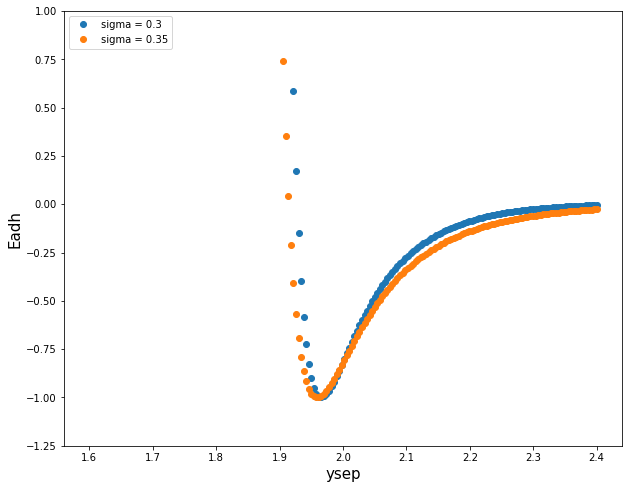

In [20]:

fig, ax = plt.subplots(1,1,figsize=(10,8))
for i in range(len(sigmas)):
    ax.plot(np.array(yseps[i]),np.array(eadhs[i]),"o",label=f"sigma = {sigmas[i][0]}")
# ax.set_xlim(0,1.5)
# ax.set_ylim(-120000,10)
ax.set_ylim(-1.25,1)
ax.legend()
ax.set_xlabel("ysep",fontsize=15)
ax.set_ylabel("Eadh",fontsize=15)

emin_list = []
tmin_list = []
for i in range(len(eadhs)):
    imin = np.argmin(eadhs[i])
    emin = np.abs(eadhs[i][imin])
    tmin = np.abs(yseps[i][imin])
    emin_list.append(emin)
    tmin_list.append(tmin)
print(f"sigma_list = np.array({sigma_list})")
print(f"epsilon_list = np.array({epsilon_list})")
print(f"emin_list = np.array({emin_list})")
print(f"tmin_list = np.array({tmin_list})")

In [21]:
emin_list

[1.00000000000215, 1.00000000000106]

In [14]:
(1/np.array(emin_list)).tolist()

[1.0422868180740177e-05, 8.583244858013735e-06]

In [214]:
1.501496-0.971 #-0.029

0.530496

In [203]:
2.28925 +0.029

2.31825

In [191]:
0.029+1.971

2.0

In [215]:
1/np.array(emin_list)

array([1.44848393e-05])

sigma_list = np.array([0.25, 0.410829, 0.636787, 0.899922])
alist = np.array([459.8342882286471, 166.06337674385122, 55.341961100230606, 27.360747870066337])
tmin_list = np.array([1.974, 1.95, 1.926, 1.893])
x0list = np.array([1.9741417522426317, 1.9534733461775418, 1.9272076344596354, 1.8971542861203823])
emin_list = np.array([0.999657200442863, 0.999650101603849, 0.999961828225116, 1.00003909142777])
y0list = np.array([-1.0001497396965455, -1.0020885036441933, -1.0000507848449882, -1.0012583914268347])
epsilon_list = np.array([1.4464536457630208e-05, 7.149441531645948e-06, 4.4305240601244645e-06, 3.0055178781968955e-06])


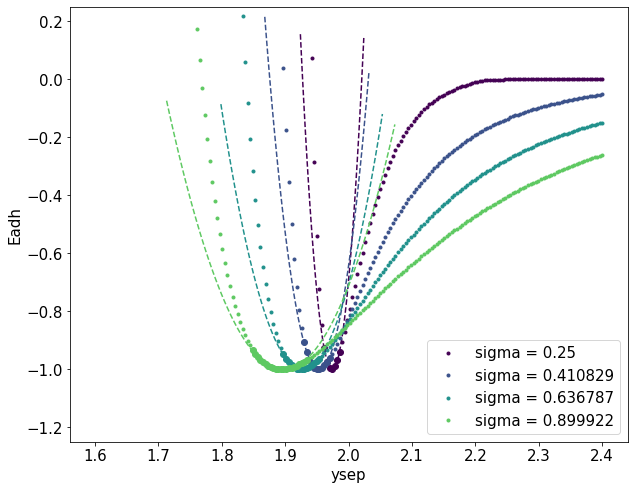

In [359]:
def harmonicfit(x,a,x0,y0):
    return a*(x-x0)**2 + y0
alist = []
x0list = []
y0list = []

cmap = plt.cm.viridis

fig, ax = plt.subplots(1,1,figsize=(10,8))
for i in range(len(sigma_list)):
    mask = (np.array(yseps[i])-tmin_list[i])**2 <= (0.05*sigma_list[i])**2
    ax.plot(np.array(yseps[i])[mask],np.array(eadhs[i])[mask],"o",color = cmap(i/(len(sigma_list))))
    ax.plot(np.array(yseps[i]),np.array(eadhs[i]),".",label=f"sigma = {sigma_list[i]}", color = cmap(i/(len(sigma_list))))
    xdata = np.array(yseps[i])[mask]
    ydata = np.array(eadhs[i])[mask]
    params, err = curve_fit(harmonicfit,xdata,ydata,p0=np.array([1,tmin_list[i],-emin_list[i]]))
    (abest,x0best,y0best)=params
    alist.append(abest)
    x0list.append(x0best)
    y0list.append(y0best)
    xfit = np.linspace(tmin_list[i]-0.2*sigma_list[i],tmin_list[i]+0.2*sigma_list[i],100)
    ax.plot(xfit,harmonicfit(xfit,abest,x0best,y0best),"--",color = cmap(i/(len(sigma_list))))
    
# ax.set_xlim(1.5,2.5)
# ax.set_ylim(-200,10)
ax.set_ylim(-1.25,0.25)
ax.legend(fontsize=15)
ax.set_xlabel("ysep",fontsize=15)
ax.set_ylabel("Eadh",fontsize=15)
ax.tick_params(labelsize=15)

print(f"sigma_list = np.array({sigma_list})")
print(f"alist = np.array({alist})")
print(f"tmin_list = np.array({tmin_list})")
print(f"x0list = np.array({x0list})")
print(f"emin_list = np.array({emin_list})")
print(f"y0list = np.array({y0list})")
print(f"epsilon_list = np.array({epsilon_list})")


In [355]:
sigmaeff_list = np.sqrt(np.abs(np.array(y0list))/np.array(alist))
sigmaeff_list

array([0.04663713, 0.07768123, 0.13442615, 0.19129742])

In [262]:
sigmaeff_list[3]/sigmaeff_list[0]

4.1018262989803445

In [263]:
sigma_list[3]/sigma_list[0]

3.599688

In [3]:
t0_list = np.array([4.434,2.35,1.2,0.6])
# t_list = t0_list + np.array(tmin_list)-1
dtlist = np.array(x0list)-1
t_list = t0_list + dtlist

t_list

NameError: name 'x0list' is not defined

In [375]:
dtlist

array([0.97414175, 0.95347335, 0.92720763, 0.89715429])

In [376]:
r0_list = np.array([54.053,32.893,21.221,15.015])
t_list/r0_list

array([0.10005257, 0.10043089, 0.10024069, 0.09971058])

In [377]:
epsilon_list

[1.4464536457630208e-05,
 7.149441531645948e-06,
 4.4305240601244645e-06,
 3.0055178781968955e-06]

In [2]:
0.007 * wx**4 / (t0_list**2 * r0_list**2)

NameError: name 'wx' is not defined

In [309]:
sigma_list

[0.25, 0.410829, 0.636787, 0.899922]

In [12]:
wx = 30
t0 = 0.6
r0 = 21.221
delta = (t0+1) * wx**2  / (8 * r0**2 )
0.13 * delta / np.sqrt((t0+1)/r0)


0.18923745470441242

In [19]:
wx = 30
t0 = 0.8
r0 = 21.221
0.007 * wx**4 / (t0**2 * r0**2)

19.673036339964995

In [21]:
delta = (t0+1) * wx**2  / (8 * r0**2 )
0.13 * delta / np.sqrt((t0+1)/r0)

0.20071663121395825

In [23]:
1.572-0.6 + 0.8

1.7720000000000002